# Pandas Cheat Sheet


In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

bois = pd.read_csv('./bios.CSV')
bois['born_date'] = pd.to_datetime(bois['born_date'])

---
## 1. Loading Data

In [6]:
# Load a CSV file into a DataFrame
df = pd.read_csv('./bios.CSV')
df = pd.read_parquet('./results.parquet')

# Load CSV with specific columns only — saves memory
df = pd.read_csv('./bios.CSV', usecols=['name', 'height_cm', 'weight_kg', 'born_country'])
df.head()


,name,born_country,height_cm,weight_kg
0,Jean-François Blanchy,FRA,NaN,NaN
1,Arnaud Boetsch,FRA,183.0,76.0
2,Jean Borotra,FRA,183.0,76.0
3,Jacques Brugnon,FRA,168.0,64.0
4,Albert Canet,GBR,NaN,NaN


---
## 2. Exploring Data — Always Do This First

In [8]:
# Show first 5 rows
bois.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25


In [9]:
# Show last 5 rows
bois.tail()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18
145499,149814,Bill Phillips,1913-07-15,Dulwich Hill,New South Wales,AUS,Australia,NaN,NaN,2003-10-20


In [10]:
# Show random 5 rows — good for spotting unexpected values
bois.sample(5)

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
14791,14891,Erik Jansson,1907-05-14,NaN,NaN,NaN,Sweden,NaN,NaN,1993-07-24
80500,81151,María Giro,1971-05-12,Buenos Aires,Ciudad Autónoma de Buenos Aires,ARG,Argentina,NaN,NaN,NaN
132332,135187,Ösökhbayaryn Chagnaadorj,1997-05-06,NaN,NaN,NaN,Mongolia,155.0,56.0,NaN
43669,44006,Libero Casali,1939-09-23,NaN,NaN,NaN,San Marino,182.0,80.0,NaN
77429,78020,Ruth Wysocki,1957-03-08,Alhambra,California,USA,United States,176.0,59.0,NaN


In [11]:
# Number of rows and columns
bois.shape

(145500, 10)

In [12]:
# Column names
bois.columns

Index(['athlete_id', 'name', 'born_date', 'born_city', 'born_region',
       'born_country', 'NOC', 'height_cm', 'weight_kg', 'died_date'],
      dtype='object')

In [13]:
# Data types of each column — important before ML preprocessing
bois.dtypes

athlete_id               int64
name                    object
born_date       datetime64[ns]
born_city               object
born_region             object
born_country            object
NOC                     object
height_cm              float64
weight_kg              float64
died_date               object
dtype: object

In [14]:
# Quick summary — shows nulls, data types, memory usage
bois.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   athlete_id    145500 non-null  int64         
 1   name          145500 non-null  object        
 2   born_date     143693 non-null  datetime64[ns]
 3   born_city     110908 non-null  object        
 4   born_region   110908 non-null  object        
 5   born_country  110908 non-null  object        
 6   NOC           145499 non-null  object        
 7   height_cm     106651 non-null  float64       
 8   weight_kg     102070 non-null  float64       
 9   died_date     33940 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 11.1+ MB


In [15]:
# Quick summary — shows nulls, data types, memory usage
bois.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145500 entries, 0 to 145499
Data columns (total 10 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   athlete_id    145500 non-null  int64         
 1   name          145500 non-null  object        
 2   born_date     143693 non-null  datetime64[ns]
 3   born_city     110908 non-null  object        
 4   born_region   110908 non-null  object        
 5   born_country  110908 non-null  object        
 6   NOC           145499 non-null  object        
 7   height_cm     106651 non-null  float64       
 8   weight_kg     102070 non-null  float64       
 9   died_date     33940 non-null   object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(6)
memory usage: 11.1+ MB


In [16]:
# Statistical summary of numeric columns
bois.describe()

,athlete_id,born_date,height_cm,weight_kg
count,145500.000000,143693,106651.000000,102070.000000
mean,73686.188955,1957-07-16 11:14:56.937220480,176.333724,71.890996
min,1.000000,1828-10-25 00:00:00,127.000000,25.000000
25%,36663.750000,1939-02-07 00:00:00,170.000000,62.000000
50%,73302.500000,1964-11-27 00:00:00,176.000000,70.000000
75%,110306.250000,1982-02-16 00:00:00,183.000000,80.000000
max,149814.000000,2009-01-01 00:00:00,226.000000,198.000000
std,42868.960158,NaN,10.380282,14.465540


In [17]:
# Count unique values per column — helps spot ID columns vs useful features
bois.nunique()

athlete_id      145500
name            142780
born_date        41279
born_city        22368
born_region       2554
born_country       236
NOC                696
height_cm           95
weight_kg          141
died_date        20009
dtype: int64

---
## 3. Selecting and Accessing Data

In [20]:
# Select a single column
bois['name']

0         Jean-François Blanchy
1                Arnaud Boetsch
2                  Jean Borotra
3               Jacques Brugnon
4                  Albert Canet
                  ...          
145495        Polina Luchnikova
145496      Valeriya Merkusheva
145497          Yuliya Smirnova
145498           André Foussard
145499            Bill Phillips
Name: name, Length: 145500, dtype: object

In [21]:
# Select multiple columns — this is how you pick features for ML
bois[['name', 'height_cm', 'weight_kg']]

,name,height_cm,weight_kg
0,Jean-François Blanchy,NaN,NaN
1,Arnaud Boetsch,183.0,76.0
2,Jean Borotra,183.0,76.0
3,Jacques Brugnon,168.0,64.0
4,Albert Canet,NaN,NaN
...,...,...,...
145495,Polina Luchnikova,167.0,61.0
145496,Valeriya Merkusheva,168.0,65.0
145497,Yuliya Smirnova,163.0,55.0
145498,André Foussard,166.0,NaN


In [22]:
# Select rows by label using loc
bois.loc[0:5]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
5,6,Nicolas Chatelain,1970-01-13,Amiens,Somme,FRA,France,181.0,70.0,NaN


In [23]:
# Select rows and specific columns using loc
bois.loc[0:5, ['name', 'height_cm']]

,name,height_cm
0,Jean-François Blanchy,NaN
1,Arnaud Boetsch,183.0
2,Jean Borotra,183.0
3,Jacques Brugnon,168.0
4,Albert Canet,NaN
5,Nicolas Chatelain,181.0


In [24]:
# Select rows and columns by position using iloc
bois.iloc[0:5, 0:3]

,athlete_id,name,born_date
0,1,Jean-François Blanchy,1886-12-12
1,2,Arnaud Boetsch,1969-04-01
2,3,Jean Borotra,1898-08-13
3,4,Jacques Brugnon,1895-05-11
4,5,Albert Canet,1878-04-17


In [25]:
# Get a single value at a specific row and column position
bois.iloc[0, 1]

'Jean-François Blanchy'

---
## 4. Filtering Data

In [26]:
# Filter rows where height is greater than 190
bois[bois['height_cm'] > 190]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
79,80,Neil Broad,1966-11-20,Cape Town,Western Cape,RSA,Great Britain,191.0,87.0,NaN
105,106,Harold Mahony,1867-02-13,Edinburgh,Scotland,GBR,Great Britain,191.0,NaN,1905-06-27
137,138,Boris Becker,1967-11-22,Leimen,Baden-Württemberg,GER,Germany,192.0,85.0,NaN
143,144,Marc-Kevin Goellner,1970-09-22,Rio de Janeiro,Rio de Janeiro,BRA,Germany,196.0,85.0,NaN
160,161,Michael Stich,1968-10-18,Pinneberg,Schleswig-Holstein,GER,Germany,192.0,79.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145257,148977,Pavol Regenda,1999-12-07,Michalovce,Košice,SVK,Slovakia,192.0,93.0,NaN
145259,148979,Juraj Slafkovský,2004-03-30,Košice,Košice,SVK,Slovakia,192.0,102.0,NaN
145261,148981,Matej Tomek,1997-05-24,Bratislava,Bratislava,SVK,Slovakia,191.0,82.0,NaN
145263,148983,Marián Skupek,2001-07-12,Gelnica,Košice,SVK,Slovakia,196.0,108.0,NaN


In [27]:
# Filter with multiple conditions using & (AND)
bois[(bois['height_cm'] > 190) & (bois['born_country'] == 'USA')]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
2225,2235,Butch Johnson,1955-08-30,Worcester,Massachusetts,USA,United States,191.0,98.0,NaN
2712,2724,Lindsay Davenport,1976-06-08,Palos Verdes,California,USA,United States,191.0,79.0,NaN
2736,2748,Jim Butler,1971-02-15,Iowa City,Iowa,USA,United States,193.0,77.0,NaN
2775,2787,Robert Seguso,1963-05-01,Minneapolis,Minnesota,USA,United States,191.0,82.0,NaN
2785,2797,Watty Washburn,1894-06-13,New York,New York,USA,United States,194.0,NaN,1973-12-02
...,...,...,...,...,...,...,...,...,...,...
143813,147469,Drew Kibler,2000-03-09,Indianapolis,Indiana,USA,United States,196.0,NaN,NaN
143836,147492,Alex Wolf,1997-04-19,Anaheim,California,USA,United States,200.0,NaN,NaN
143838,147494,Drew Holland,1995-04-11,Berkeley,California,USA,United States,195.0,NaN,NaN
143984,147642,Keldon Johnson,1999-10-11,Chesterfield,Virginia,USA,United States,196.0,NaN,NaN


In [28]:
# Filter with multiple conditions using | (OR)
bois[(bois['born_country'] == 'USA') | (bois['born_country'] == 'GBR')]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
37,38,Helen Aitchison,1881-12-06,Sunderland,England,GBR,Great Britain,NaN,NaN,1947-05-26
38,39,Geraldine Beamish,1883-06-23,Forest Gate,England,GBR,Great Britain,NaN,NaN,1972-05-10
39,40,Dora Boothby,1881-08-02,Finchley,England,GBR,Great Britain,NaN,NaN,1970-02-22
40,41,Julie Bradbury,1967-02-12,Oxford,England,GBR,Great Britain,175.0,64.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145445,149168,Kristen Santos,1994-11-02,Fairfield,Connecticut,USA,United States,NaN,NaN,NaN
145446,149169,Corinne Stoddard,2001-08-15,Seattle,Washington,USA,United States,NaN,NaN,NaN
145454,149180,Anna Hoffmann,2000-03-28,Madison,Wisconsin,USA,United States,NaN,NaN,NaN
145457,149183,Alix Wilkinson,2000-08-02,Mammoth Lakes,California,USA,United States,NaN,NaN,NaN


In [29]:
# Filter rows where country is in a list — cleaner way to do multiple OR conditions
bois[bois['born_country'].isin(['USA', 'GBR', 'FRA'])]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25
...,...,...,...,...,...,...,...,...,...,...
145454,149180,Anna Hoffmann,2000-03-28,Madison,Wisconsin,USA,United States,NaN,NaN,NaN
145457,149183,Alix Wilkinson,2000-08-02,Mammoth Lakes,California,USA,United States,NaN,NaN,NaN
145467,149194,Elisa Nakab,1998-05-08,Briançon,Hautes-Alpes,FRA,Italy,NaN,NaN,NaN
145468,149195,Justin Abdelkader,1987-02-25,Muskegon,Michigan,USA,United States,187.0,97.0,NaN


In [30]:
# Filter rows where name contains a specific string
bois[bois['name'].str.contains('Keith', case=False, na=False)]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1897,1907,Keith Hanlon,1966-09-01,NaN,NaN,NaN,Ireland,NaN,NaN,NaN
3505,3517,Keith Wallace,1961-03-29,Preston,England,GBR,Great Britain,165.0,51.0,1999-12-31
6228,6255,Keith Hartley,1940-10-15,Vancouver,British Columbia,CAN,Canada,200.0,85.0,NaN
8898,8946,Keith Mwila,1966-01-01,NaN,NaN,NaN,Zambia,NaN,NaN,1993-01-09
12053,12118,Keith Hervey,1898-11-03,Fulham,England,GBR,Great Britain,NaN,NaN,1973-02-22
...,...,...,...,...,...,...,...,...,...,...
109900,111105,Keith Cumberpatch,1927-08-25,Christchurch,Canterbury,NZL,New Zealand,NaN,NaN,2013-11-15
115973,117348,Keith Sanderson,1975-02-02,Plymouth,Massachusetts,USA,United States,183.0,95.0,NaN
117676,119195,Duncan Keith,1983-07-16,Winnipeg,Manitoba,CAN,Canada,185.0,88.0,NaN
122121,124176,Keith Ferguson,1979-09-07,Sale,Victoria,AUS,Australia,176.0,78.0,NaN


In [31]:
# Filter using query — cleaner syntax for simple conditions
bois.query('born_country == "USA" and height_cm > 180')

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1375,1382,Lori Harrigan,1970-09-05,Anaheim,California,USA,United States,182.0,99.0,NaN
2206,2216,Ruth Rowe,1947-03-11,Pittsburgh,Pennsylvania,USA,United States,185.0,63.0,NaN
2213,2223,Jay Barrs,1962-07-17,Jacksonville,Florida,USA,United States,182.0,70.0,NaN
2221,2231,Ed Eliason,1938-05-01,Port Gamble,Washington,USA,United States,189.0,86.0,NaN
2225,2235,Butch Johnson,1955-08-30,Worcester,Massachusetts,USA,United States,191.0,98.0,NaN
...,...,...,...,...,...,...,...,...,...,...
144099,147767,D. J. Sharabi,1992-03-07,San Mateo,California,USA,Israel,182.0,NaN,NaN
144398,148088,Jian An,1990-09-15,Irvine,California,USA,People's Republic of China,187.0,86.0,NaN
144400,148090,Shimisi Jieruimi,1989-04-13,Dearborn,Michigan,USA,People's Republic of China,183.0,80.0,NaN
144977,148686,Atle Lie McGrath,2000-04-21,Burlington,Vermont,USA,Norway,182.0,NaN,NaN


---
## 5. Sorting

In [32]:
# Sort by height — ascending by default
bois.sort_values('height_cm')

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
4515,4530,Lyton Mphande,1963-05-14,NaN,NaN,NaN,Malawi,127.0,62.0,NaN
28619,28832,Rosario Briones,1953-10-05,San Luis Potosí,San Luis Potosí,MEX,Mexico,127.0,42.0,NaN
4516,4531,Helman Palije,1967-06-24,NaN,NaN,NaN,Malawi,128.0,74.0,NaN
4664,4681,Salvador Miranda,1949-09-13,NaN,NaN,NaN,Nicaragua,130.0,51.0,NaN
4517,4532,Boston Simbeye,1959-12-24,NaN,NaN,NaN,Malawi,130.0,67.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145490,149217,Sin Ye-Chan,1995-06-13,NaN,NaN,NaN,Republic of Korea,NaN,NaN,NaN
145491,149218,Matthew Wepke,1989-12-05,NaN,NaN,NaN,Jamaica,NaN,NaN,NaN
145492,149219,Carlos García-Ordóñez,1927-04-24,La Habana (Havana),Ciudad de La Habana,CUB,Cuba,NaN,NaN,2019-11-24
145493,149220,Landysh Falyakhova,1998-08-31,Dva Polya Artash,Respublika Tatarstan,RUS,ROC,NaN,NaN,NaN


In [33]:
# Sort descending — tallest first
bois.sort_values('height_cm', ascending=False)

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
89070,89782,Yao Ming,1980-09-12,Xuhui District,Shanghai,CHN,People's Republic of China,226.0,141.0,NaN
6978,7013,Arvydas Sabonis,1964-12-19,Kaunas,Kaunas,LTU,Lithuania Soviet Union,223.0,122.0,NaN
5781,5804,Tommy Burleson,1952-02-24,Crossnore,North Carolina,USA,United States,223.0,102.0,NaN
89075,89787,Roberto Dueñas,1975-11-01,Madrid,Madrid,ESP,Spain,221.0,137.0,NaN
120266,122147,Zhang Zhaoxu,1987-11-18,Binzhou,Shandong,CHN,People's Republic of China,221.0,110.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145490,149217,Sin Ye-Chan,1995-06-13,NaN,NaN,NaN,Republic of Korea,NaN,NaN,NaN
145491,149218,Matthew Wepke,1989-12-05,NaN,NaN,NaN,Jamaica,NaN,NaN,NaN
145492,149219,Carlos García-Ordóñez,1927-04-24,La Habana (Havana),Ciudad de La Habana,CUB,Cuba,NaN,NaN,2019-11-24
145493,149220,Landysh Falyakhova,1998-08-31,Dva Polya Artash,Respublika Tatarstan,RUS,ROC,NaN,NaN,NaN


In [34]:
# Sort by multiple columns
bois.sort_values(['born_country', 'height_cm'], ascending=[True, False])

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
116031,117410,Rohullah Nikpai,1987-06-15,Kabul,Kabul,AFG,Afghanistan,183.0,NaN,NaN
56661,57065,Ghulam Dastagir,1945-07-24,Kabul,Kabul,AFG,Afghanistan,180.0,87.0,NaN
103917,104914,Robina Muqim Yaar,1986-07-03,Kabul,Kabul,AFG,Afghanistan,180.0,56.0,NaN
63783,64263,Abdul Wardak,1940-08-15,Kabul,Kabul,AFG,Afghanistan,179.0,75.0,NaN
63781,64261,Abdul Hadi Shekaib,1940-04-27,Kabul,Kabul,AFG,Afghanistan,178.0,68.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145484,149211,Gao Hongbo,2000-10-20,NaN,NaN,NaN,People's Republic of China,NaN,NaN,NaN
145486,149213,Dmitry Karlagachev,1998-10-13,NaN,NaN,NaN,ROC,NaN,NaN,NaN
145489,149216,Ye Jielong,2000-03-02,NaN,NaN,NaN,People's Republic of China,NaN,NaN,NaN
145490,149217,Sin Ye-Chan,1995-06-13,NaN,NaN,NaN,Republic of Korea,NaN,NaN,NaN


---
## 6. Handling Missing Values — Critical for ML

In [35]:
# Check how many null values exist in each column
bois.isnull().sum()

athlete_id           0
name                 0
born_date         1807
born_city        34592
born_region      34592
born_country     34592
NOC                  1
height_cm        38849
weight_kg        43430
died_date       111560
dtype: int64

In [36]:
# Check null percentage per column — helps decide whether to drop or fill
(bois.isnull().sum() / len(bois)) * 100

athlete_id       0.000000
name             0.000000
born_date        1.241924
born_city       23.774570
born_region     23.774570
born_country    23.774570
NOC              0.000687
height_cm       26.700344
weight_kg       29.848797
died_date       76.673540
dtype: float64

In [37]:
# Drop rows that have any null values
bois.dropna()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
107,108,Anders Nielsen,1967-02-24,Cape Town,Western Cape,RSA,Great Britain,173.0,70.0,2010-07-29
258,259,Tonny Maringgi,1959-06-10,Kendari,Sulawesi Tenggara,INA,Indonesia,167.0,65.0,2019-09-15
300,301,Jackson Fear,1978-01-13,Sydney,New South Wales,AUS,Australia,178.0,125.0,2006-07-21
...,...,...,...,...,...,...,...,...,...,...
135272,138435,Art Child,1916-09-15,West Ham,England,GBR,Great Britain,180.0,71.0,1996-06-30
135277,138440,Toyoko Yoshino,1920-02-12,Abashiri,Hokkaido,JPN,Japan,159.0,54.0,2015-01-24
135283,138446,Jacques Demaré,1900-09-01,Vincennes,Val-de-Marne,FRA,France,185.0,78.0,1935-12-09
136653,139884,Johanna Bassani,2002-04-25,Vöcklabruck,Oberösterreich,AUT,Austria,163.0,54.0,2020-05-05


In [38]:
# Drop rows only where specific column is null
bois.dropna(subset=['height_cm'])

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
5,6,Nicolas Chatelain,1970-01-13,Amiens,Somme,FRA,France,181.0,70.0,NaN
6,7,Patrick Chila,1969-11-27,Ris-Orangis,Essonne,FRA,France,180.0,73.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145494,149221,George Wright,1890-07-21,Toronto,Ontario,CAN,Canada,183.0,NaN,1973-01-28
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN


In [39]:
# Drop columns where more than 50% values are missing
bois.dropna(thresh=len(bois)*0.5, axis=1)

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN
...,...,...,...,...,...,...,...,...,...
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN


In [40]:
# Fill null values with a fixed value
bois['height_cm'].fillna(0)

0           0.0
1         183.0
2         183.0
3         168.0
4           0.0
          ...  
145495    167.0
145496    168.0
145497    163.0
145498    166.0
145499      0.0
Name: height_cm, Length: 145500, dtype: float64

In [41]:
# Fill null values with mean — most common strategy for numeric columns
bois['height_cm'].fillna(bois['height_cm'].mean())

0         176.333724
1         183.000000
2         183.000000
3         168.000000
4         176.333724
             ...    
145495    167.000000
145496    168.000000
145497    163.000000
145498    166.000000
145499    176.333724
Name: height_cm, Length: 145500, dtype: float64

In [42]:
# Fill null values with median — better when data has outliers
bois['height_cm'].fillna(bois['height_cm'].median())

0         176.0
1         183.0
2         183.0
3         168.0
4         176.0
          ...  
145495    167.0
145496    168.0
145497    163.0
145498    166.0
145499    176.0
Name: height_cm, Length: 145500, dtype: float64

In [43]:
# Fill null values with mode — best for categorical columns
bois['born_country'].fillna(bois['born_country'].mode()[0])

0         FRA
1         FRA
2         FRA
3         FRA
4         GBR
         ... 
145495    RUS
145496    RUS
145497    RUS
145498    FRA
145499    AUS
Name: born_country, Length: 145500, dtype: object

In [44]:
# Fill using interpolation — estimates missing value based on surrounding values
bois['height_cm'].interpolate()

0           NaN
1         183.0
2         183.0
3         168.0
4         174.5
          ...  
145495    167.0
145496    168.0
145497    163.0
145498    166.0
145499    166.0
Name: height_cm, Length: 145500, dtype: float64

In [45]:
# Keep only rows where a column is NOT null
bois[bois['height_cm'].notna()]

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20
5,6,Nicolas Chatelain,1970-01-13,Amiens,Somme,FRA,France,181.0,70.0,NaN
6,7,Patrick Chila,1969-11-27,Ris-Orangis,Essonne,FRA,France,180.0,73.0,NaN
...,...,...,...,...,...,...,...,...,...,...
145494,149221,George Wright,1890-07-21,Toronto,Ontario,CAN,Canada,183.0,NaN,1973-01-28
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN


---
## 7. Feature Engineering — Where ML Prep Really Happens

In [ ]:
# Create a new column from existing columns
bois['height_weight_ratio'] = bois['height_cm'] / bois['weight_kg']

# Extract year from a date column as a new feature
bois['birth_year'] = bois['born_date'].dt.year

# Extract month from date
bois['birth_month'] = bois['born_date'].dt.month

# Use apply() with lambda — transform each value in a column using custom logic
bois['is_tall'] = bois['height_cm'].apply(lambda x: 1 if x > 190 else 0)

# apply() on text — extract first name from full name
bois['first_name'] = bois['name'].apply(lambda x: x.split()[0] if isinstance(x, str) else x)

# pd.cut() — bin a continuous column into categories
bois['height_category'] = pd.cut(
    bois['height_cm'],
    bins=[0, 165, 180, 195, 300],
    labels=['Short', 'Medium', 'Tall', 'Very Tall']
)

# Rename columns — clean column names before passing to ML model
bois.rename(columns={'height_cm': 'height', 'weight_kg': 'weight'}, inplace=True)

# Drop columns that are not useful as ML features
bois.drop(columns=['born_date', 'first_name'], inplace=True)

# Reset index after filtering or dropping rows
bois.reset_index(drop=True, inplace=True)

In [48]:
# Create a new column from existing columns
bois['height_weight_ratio'] = bois['height_cm'] / bois['weight_kg']
bois.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,height_weight_ratio
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,NaN
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,2.407895
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,2.407895
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,2.625000
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,NaN


In [51]:
# Extract year from a date column as a new feature
bois['birth_year'] = bois['born_date'].dt.year
bois.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,height_weight_ratio,birth_year
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,NaN,1886.0
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,2.407895,1969.0
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,2.407895,1898.0
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,2.625000,1895.0
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,NaN,1878.0


In [53]:
# Extract month from date
bois['birth_month'] = bois['born_date'].dt.month
bois.head()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,height_weight_ratio,birth_year,birth_month
0,1,Jean-François Blanchy,1886-12-12,Bordeaux,Gironde,FRA,France,NaN,NaN,1960-10-02,NaN,1886.0,12.0
1,2,Arnaud Boetsch,1969-04-01,Meulan,Yvelines,FRA,France,183.0,76.0,NaN,2.407895,1969.0,4.0
2,3,Jean Borotra,1898-08-13,Biarritz,Pyrénées-Atlantiques,FRA,France,183.0,76.0,1994-07-17,2.407895,1898.0,8.0
3,4,Jacques Brugnon,1895-05-11,Paris VIIIe,Paris,FRA,France,168.0,64.0,1978-03-20,2.625000,1895.0,5.0
4,5,Albert Canet,1878-04-17,Wandsworth,England,GBR,France,NaN,NaN,1930-07-25,NaN,1878.0,4.0


In [56]:
# Use apply() with lambda — transform each value in a column using custom logic
bois['is_tall'] = bois['height_cm'].apply(lambda x: 1 if x > 190 else 0)
bois.tail()

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,height_weight_ratio,birth_year,birth_month,is_tall
145495,149222,Polina Luchnikova,2002-01-30,Serov,Sverdlovsk,RUS,ROC,167.0,61.0,NaN,2.737705,2002.0,1.0,0
145496,149223,Valeriya Merkusheva,1999-09-20,Moskva (Moscow),Moskva,RUS,ROC,168.0,65.0,NaN,2.584615,1999.0,9.0,0
145497,149224,Yuliya Smirnova,1998-05-08,Kotlas,Arkhangelsk,RUS,ROC,163.0,55.0,NaN,2.963636,1998.0,5.0,0
145498,149225,André Foussard,1899-05-19,Niort,Deux-Sèvres,FRA,France,166.0,NaN,1986-03-18,NaN,1899.0,5.0,0
145499,149814,Bill Phillips,1913-07-15,Dulwich Hill,New South Wales,AUS,Australia,NaN,NaN,2003-10-20,NaN,1913.0,7.0,0


In [60]:
# apply() on text — extract first name from full name
bois['first_name'] = bois['name'].apply(lambda x: x.split()[0] if isinstance(x, str) else x)
bois.sample(5)

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,height_weight_ratio,birth_year,birth_month,is_tall,first_name
43115,43448,Joop van Domselaar,1928-09-11,Driebergen,Utrecht,NED,Netherlands,183.0,92.0,2006-11-11,1.989130,1928.0,9.0,0,Joop
57151,57557,Adrien Poliquin,1929-04-10,Victoriaville,Québec,CAN,Canada,NaN,NaN,2012-06-14,NaN,1929.0,4.0,0,Adrien
72781,73335,Mohamed Lahcen,1931-01-01,Meknès,Fès-Meknès,MAR,Morocco,174.0,61.0,NaN,2.852459,1931.0,1.0,0,Mohamed
61991,62447,Andrés Isola,1974-12-20,NaN,NaN,NaN,Uruguay,NaN,NaN,NaN,NaN,1974.0,12.0,0,Andrés
114770,116090,Vadzim Kaptur,1987-07-12,Minsk,Minsk,BLR,Belarus,174.0,67.0,NaN,2.597015,1987.0,7.0,0,Vadzim


In [62]:
# pd.cut() — bin a continuous column into categories
bois['height_category'] = pd.cut(
    bois['height_cm'],
    bins=[0, 165, 180, 195, 300],
    labels=['Short', 'Medium', 'Tall', 'Very Tall']
)
bois.sample(6)

,athlete_id,name,born_date,born_city,born_region,born_country,NOC,height_cm,weight_kg,died_date,height_weight_ratio,birth_year,birth_month,is_tall,first_name,height_category
140751,144273,Shawn Rowe,1992-12-07,NaN,NaN,NaN,Jamaica,NaN,NaN,NaN,NaN,1992.0,12.0,0,Shawn,NaN
6827,6860,Aleksandar Petrović,1959-02-16,Šibenik,Šibensko-kninska županija,CRO,Croatia Yugoslavia,194.0,85.0,NaN,2.282353,1959.0,2.0,1,Aleksandar,Tall
110762,111988,Natália Bernardo-Santos,1986-12-25,Luanda,Luanda,ANG,Angola,170.0,65.0,NaN,2.615385,1986.0,12.0,0,Natália,Medium
29966,30192,Edgar Watkins,1887-05-12,Ferndale,Wales,GBR,Great Britain,NaN,NaN,1960-01-01,NaN,1887.0,5.0,0,Edgar,NaN
67608,68119,Albert Champoudry,1880-05-08,Paris XIIIe,Paris,FRA,France,177.0,NaN,1933-06-23,NaN,1880.0,5.0,0,Albert,Medium
94124,94885,George Cosac,1968-01-26,Constanța,Constanța,ROU,Romania,190.0,84.0,NaN,2.261905,1968.0,1.0,0,George,Tall


In [148]:
# Rename columns — clean column names before passing to ML model
bois.rename(columns={'height_cm': 'height', 'weight_kg': 'weight'}, inplace=True)
bois.sample(5)

,athlete_id,name,born_city,born_region,born_country,height,weight,height_weight_ratio,birth_year,birth_month
122285,124354,Saskia van Erven,Rotterdam,Zuid-Holland,NED,175.0,64.0,2.734375,1987.0,8.0
131517,134311,Hannibal Gaskin,Georgetown,Demerara-Mahaica,GUY,173.0,68.0,2.544118,1997.0,8.0
41604,41922,Miguel Marina,La Habana (Havana),Ciudad de La Habana,CUB,177.0,76.0,2.328947,1928.0,1.0
17229,17347,Mariana Arnal,NaN,NaN,NaN,NaN,NaN,NaN,1973.0,8.0
140464,143974,Mitchell Glasser,Chicago,Illinois,USA,180.0,NaN,NaN,1989.0,10.0


In [152]:
# Reset index after filtering or dropping rows
bois.reset_index(drop=True, inplace=True)
bois.sample(5)

,athlete_id,name,born_city,born_region,born_country,height,weight,height_weight_ratio,birth_year,birth_month
60236,60668,Dick Hutton,Amarillo,Texas,USA,NaN,NaN,NaN,1923.0,10.0
136609,139838,Yuto Nishikata,NaN,NaN,NaN,NaN,NaN,NaN,2003.0,2.0
83714,84378,Adam Brodecki,Łódź,Łódzkie,POL,179.0,70.0,2.557143,1949.0,8.0
95826,96600,Charles Proctor,Columbia,Missouri,USA,NaN,NaN,NaN,1906.0,1.0
119941,121784,Allegra Lapi,Bagno a Ripoli,Firenze,ITA,163.0,55.0,2.963636,1985.0,9.0


---
## 8. Encoding Categorical Data — ML Models Only Understand Numbers

In [153]:
# Check which columns are categorical and need encoding
bois.select_dtypes(include='object').columns

Index(['name', 'born_city', 'born_region', 'born_country'], dtype='object')

In [154]:
# One-hot encoding — creates a separate 0/1 column for each category
# Best when column has fewer unique values (under 10-15)
encoded = pd.get_dummies(bois, columns=['born_country'])
encoded.head()

,athlete_id,name,born_city,born_region,height,weight,height_weight_ratio,birth_year,birth_month,born_country_AFG,...,born_country_UZB,born_country_Upland,born_country_VAN,born_country_VEN,born_country_VIE,born_country_VIN,born_country_Vienna,born_country_YEM,born_country_ZAM,born_country_ZIM
0,1,Jean-François Blanchy,Bordeaux,Gironde,NaN,NaN,NaN,1886.0,12.0,False,...,False,False,False,False,False,False,False,False,False,False
1,2,Arnaud Boetsch,Meulan,Yvelines,183.0,76.0,2.407895,1969.0,4.0,False,...,False,False,False,False,False,False,False,False,False,False
2,3,Jean Borotra,Biarritz,Pyrénées-Atlantiques,183.0,76.0,2.407895,1898.0,8.0,False,...,False,False,False,False,False,False,False,False,False,False
3,4,Jacques Brugnon,Paris VIIIe,Paris,168.0,64.0,2.625000,1895.0,5.0,False,...,False,False,False,False,False,False,False,False,False,False
4,5,Albert Canet,Wandsworth,England,NaN,NaN,NaN,1878.0,4.0,False,...,False,False,False,False,False,False,False,False,False,False


In [162]:
# Label Encoding — converts each category to a number (USA=0, GBR=1, etc.)
# Best when column has many unique values
le = LabelEncoder()
bois['country_encoded'] = le.fit_transform(bois['born_country'].fillna('Unknown'))
bois.sample(5)

,athlete_id,name,born_city,born_region,born_country,height,weight,height_weight_ratio,birth_year,birth_month,country_encoded
112599,113871,Juan Fernández,Oviedo,Asturias,ESP,174.0,73.0,2.383562,1985.0,6.0,65
122998,125153,Hossam Hassan,Al-Qahira (Cairo),Al-Qahira,EGY,174.0,73.0,2.383562,1989.0,4.0,62
6412,6443,Jan Kozák,Brno,Jihomoravský kraj,CZE,NaN,NaN,NaN,1929.0,7.0,54
113032,114321,Krzysztof Gierczyński,Gubin,Lubuskie,POL,193.0,81.0,2.382716,1976.0,1.0,174
37833,38133,Róbert Éder,Košice,Košice,SVK,180.0,74.0,2.432432,1888.0,10.0,202


In [195]:
# Check how many unique values a column has before deciding encoding type
bois['born_country'].nunique()

236

---
## 9. GroupBy and Aggregation

In [163]:
# Count how many athletes per country
bois['born_country'].value_counts()

born_country
USA       9641
GER       6891
GBR       5792
FRA       5143
ITA       4709
          ... 
SEY          1
SMT          1
COK          1
Corfu        1
Aarhus       1
Name: count, Length: 236, dtype: int64

In [165]:
# Average height grouped by country
bois.groupby('born_country')['height'].mean()


born_country
AFG       170.416667
AGU       186.000000
ALB       174.657895
ALG       176.489362
AND       172.096774
             ...    
VIN       181.200000
Vienna    171.000000
YEM       169.000000
ZAM       173.192308
ZIM       173.540000
Name: height, Length: 236, dtype: float64

In [167]:
# Multiple aggregations on one column
bois.groupby('born_country')['height'].agg(['mean', 'min', 'max', 'count'])

,mean,min,max,count
born_country,,,,
AFG,170.416667,160.0,183.0,24
AGU,186.000000,186.0,186.0,1
ALB,174.657895,159.0,195.0,38
ALG,176.489362,155.0,196.0,141
AND,172.096774,160.0,185.0,31
...,...,...,...,...
VIN,181.200000,173.0,187.0,5
Vienna,171.000000,164.0,183.0,3
YEM,169.000000,160.0,175.0,4


In [168]:
# Group by multiple columns
bois.groupby(['born_country', 'born_region'])['height'].mean()

born_country  born_region       
AFG           Kabul                 170.652174
              Kandahar              165.000000
AGU           Anguilla              186.000000
ALB           Dibër                 159.000000
              Durrës                172.500000
                                       ...    
ZIM           Mashonaland East      186.500000
              Mashonaland West      177.000000
              Masvingo              171.500000
              Matabeleland South    160.000000
              Midlands              174.000000
Name: height, Length: 2616, dtype: float64

In [169]:
# Aggregate multiple columns at once
bois.groupby('born_country').agg({'height': 'mean', 'weight': 'mean'})

,height,weight
born_country,,
AFG,170.416667,68.521739
AGU,186.000000,78.000000
ALB,174.657895,76.027778
ALG,176.489362,68.043796
AND,172.096774,67.451613
...,...,...
VIN,181.200000,70.600000
Vienna,171.000000,70.666667
YEM,169.000000,55.250000


In [171]:
# Pivot table — like GroupBy but in table form
pd.pivot_table(bois, values='height', index='born_country', aggfunc='mean')

,height
born_country,
AFG,170.416667
AGU,186.000000
ALB,174.657895
ALG,176.489362
AND,172.096774
...,...
VIN,181.200000
Vienna,171.000000
YEM,169.000000


---
## 10. Merging and Joining

In [173]:
nocs = pd.read_csv('./noc_regions.CSV')

# Merge two DataFrames on matching columns — like SQL JOIN
merged = pd.merge(bois, nocs, left_on='born_country', right_on='NOC', how='left')
merged.head()

,athlete_id,name,born_city,born_region,born_country,height,weight,height_weight_ratio,birth_year,birth_month,country_encoded,NOC,region,notes
0,1,Jean-François Blanchy,Bordeaux,Gironde,FRA,NaN,NaN,NaN,1886.0,12.0,74,FRA,France,NaN
1,2,Arnaud Boetsch,Meulan,Yvelines,FRA,183.0,76.0,2.407895,1969.0,4.0,74,FRA,France,NaN
2,3,Jean Borotra,Biarritz,Pyrénées-Atlantiques,FRA,183.0,76.0,2.407895,1898.0,8.0,74,FRA,France,NaN
3,4,Jacques Brugnon,Paris VIIIe,Paris,FRA,168.0,64.0,2.625000,1895.0,5.0,74,FRA,France,NaN
4,5,Albert Canet,Wandsworth,England,GBR,NaN,NaN,NaN,1878.0,4.0,78,GBR,UK,NaN


In [174]:
# Inner join — keep only rows that match in both DataFrames
pd.merge(bois, nocs, left_on='born_country', right_on='NOC', how='inner')

,athlete_id,name,born_city,born_region,born_country,height,weight,height_weight_ratio,birth_year,birth_month,country_encoded,NOC,region,notes
0,1,Jean-François Blanchy,Bordeaux,Gironde,FRA,NaN,NaN,NaN,1886.0,12.0,74,FRA,France,NaN
1,2,Arnaud Boetsch,Meulan,Yvelines,FRA,183.0,76.0,2.407895,1969.0,4.0,74,FRA,France,NaN
2,3,Jean Borotra,Biarritz,Pyrénées-Atlantiques,FRA,183.0,76.0,2.407895,1898.0,8.0,74,FRA,France,NaN
3,4,Jacques Brugnon,Paris VIIIe,Paris,FRA,168.0,64.0,2.625000,1895.0,5.0,74,FRA,France,NaN
4,5,Albert Canet,Wandsworth,England,GBR,NaN,NaN,NaN,1878.0,4.0,78,GBR,UK,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
110634,149222,Polina Luchnikova,Serov,Sverdlovsk,RUS,167.0,61.0,2.737705,2002.0,1.0,182,RUS,Russia,NaN
110635,149223,Valeriya Merkusheva,Moskva (Moscow),Moskva,RUS,168.0,65.0,2.584615,1999.0,9.0,182,RUS,Russia,NaN
110636,149224,Yuliya Smirnova,Kotlas,Arkhangelsk,RUS,163.0,55.0,2.963636,1998.0,5.0,182,RUS,Russia,NaN
110637,149225,André Foussard,Niort,Deux-Sèvres,FRA,166.0,NaN,NaN,1899.0,5.0,74,FRA,France,NaN


In [175]:
# Outer join — keep all rows from both, fill missing with NaN
pd.merge(bois, nocs, left_on='born_country', right_on='NOC', how='outer')

,athlete_id,name,born_city,born_region,born_country,height,weight,height_weight_ratio,birth_year,birth_month,country_encoded,NOC,region,notes
0,57056.0,Mohammad Ebrahimi,Kabul,Kabul,AFG,160.0,63.0,2.539683,1930.0,4.0,0.0,AFG,Afghanistan,NaN
1,57062.0,Kayum Ayub,Kabul,Kabul,AFG,176.0,78.0,2.256410,1947.0,6.0,0.0,AFG,Afghanistan,NaN
2,57064.0,Aka-Jahan Dastagir,Kabul,Kabul,AFG,170.0,70.0,2.428571,1946.0,6.0,0.0,AFG,Afghanistan,NaN
3,57065.0,Ghulam Dastagir,Kabul,Kabul,AFG,180.0,87.0,2.068966,1945.0,7.0,0.0,AFG,Afghanistan,NaN
4,57066.0,Ahmad Djan,Kabul,Kabul,AFG,165.0,52.0,3.173077,1948.0,2.0,0.0,AFG,Afghanistan,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
145522,149211.0,Gao Hongbo,NaN,NaN,NaN,NaN,NaN,NaN,2000.0,10.0,227.0,NaN,NaN,NaN
145523,149213.0,Dmitry Karlagachev,NaN,NaN,NaN,NaN,NaN,NaN,1998.0,10.0,227.0,NaN,NaN,NaN
145524,149216.0,Ye Jielong,NaN,NaN,NaN,NaN,NaN,NaN,2000.0,3.0,227.0,NaN,NaN,NaN
145525,149217.0,Sin Ye-Chan,NaN,NaN,NaN,NaN,NaN,NaN,1995.0,6.0,227.0,NaN,NaN,NaN


In [177]:
# Stack two DataFrames vertically — both must have same columns
usa = bois[bois['born_country'] == 'USA']
gbr = bois[bois['born_country'] == 'GBR']
combined = pd.concat([usa, gbr], ignore_index=True)
combined.head()

,athlete_id,name,born_city,born_region,born_country,height,weight,height_weight_ratio,birth_year,birth_month,country_encoded
0,55,Monique Javer,Burlingame,California,USA,177.0,64.0,2.765625,1967.0,7.0,225
1,964,Xóchitl Escobedo,West Covina,California,USA,170.0,60.0,2.833333,1968.0,9.0,225
2,965,Angélica Gavaldón,El Centro,California,USA,160.0,54.0,2.962963,1973.0,10.0,225
3,1238,Bert Schneider,Cleveland,Ohio,USA,NaN,NaN,NaN,1897.0,7.0,225
4,1352,Laura Berg,Santa Fe Springs,California,USA,168.0,61.0,2.754098,1975.0,1.0,225


---
## 11. Correlation Analysis — Finding What Actually Matters

In [180]:
# Select only numeric columns for correlation
numeric_cols = bois.select_dtypes(include=np.number)
numeric_cols.head(5)

,athlete_id,height,weight,height_weight_ratio,birth_year,birth_month,country_encoded
0,1,NaN,NaN,NaN,1886.0,12.0,74
1,2,183.0,76.0,2.407895,1969.0,4.0,74
2,3,183.0,76.0,2.407895,1898.0,8.0,74
3,4,168.0,64.0,2.625000,1895.0,5.0,74
4,5,NaN,NaN,NaN,1878.0,4.0,78


In [181]:
# Compute correlation matrix — values between -1 and 1
# Closer to 1 or -1 = strong relationship, closer to 0 = weak relationship
numeric_cols.corr()

,athlete_id,height,weight,height_weight_ratio,birth_year,birth_month,country_encoded
athlete_id,1.000000,-0.000378,0.005498,0.011238,0.614690,0.002225,-0.028770
height,-0.000378,1.000000,0.779290,-0.651453,0.006908,-0.014813,-0.048411
weight,0.005498,0.779290,1.000000,-0.947003,-0.037957,-0.017381,-0.038239
height_weight_ratio,0.011238,-0.651453,-0.947003,1.000000,0.077377,0.017102,0.032049
birth_year,0.614690,0.006908,-0.037957,0.077377,1.000000,0.004544,0.004410
birth_month,0.002225,-0.014813,-0.017381,0.017102,0.004544,1.000000,-0.015058
country_encoded,-0.028770,-0.048411,-0.038239,0.032049,0.004410,-0.015058,1.000000


In [194]:
# Find which features are most correlated with height
numeric_cols.corr()['height'].sort_values(ascending=False)

height                 1.000000
weight                 0.779290
birth_year             0.006908
athlete_id            -0.000378
birth_month           -0.014813
country_encoded       -0.048411
height_weight_ratio   -0.651453
Name: height, dtype: float64

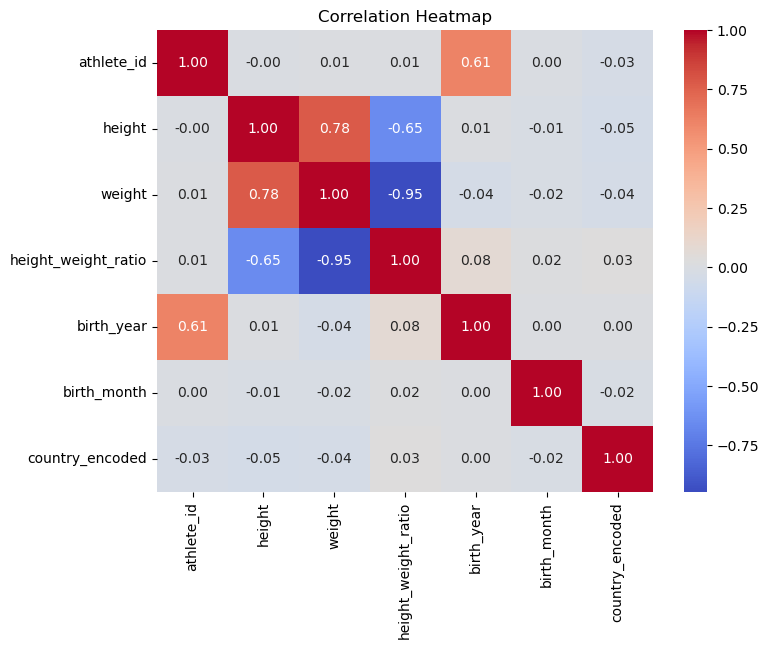

In [182]:
# Visualize correlation as a heatmap — easiest way to read relationships
plt.figure(figsize=(8, 6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [183]:
# Find and drop columns that are too highly correlated with each other
# Keeping both adds no value to the model
corr_matrix = numeric_cols.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [col for col in upper.columns if any(upper[col] > 0.9)]
print('Redundant columns to drop:', to_drop)

Redundant columns to drop: ['height_weight_ratio']


---
## 12. Final ML Prep — Putting It All Together

In [184]:
# Check data types before passing to model — everything should be numeric
bois.dtypes

athlete_id               int64
name                    object
born_city               object
born_region             object
born_country            object
height                 float64
weight                 float64
height_weight_ratio    float64
birth_year             float64
birth_month            float64
country_encoded          int64
dtype: object

In [185]:
# Check for remaining null values before passing to model
bois.isnull().sum()

athlete_id                 0
name                       0
born_city              34592
born_region            34592
born_country           34592
height                 38849
weight                 43430
height_weight_ratio    43430
birth_year              1807
birth_month             1807
country_encoded            0
dtype: int64

In [191]:
# Select your feature columns (X) and target column (y)
X = bois[['height', 'weight', 'birth_year', 'country_encoded']]
y = bois['birth_month']

# Confirm shapes are correct before passing to model
print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (145500, 4)
Target shape: (145500,)


In [192]:
# Check class balance in target column — important for classification problems
y.value_counts()

birth_month
1.0     15410
3.0     12831
5.0     12183
4.0     12021
2.0     11974
7.0     11745
9.0     11605
8.0     11491
6.0     11328
10.0    11303
12.0    11036
11.0    10766
Name: count, dtype: int64